## 1.LOAD DATASET


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("student-mat.csv", sep=';', encoding='utf-8')
print("data load")

data load


## 2. EXPLORE AND CLEAN DATA



In [15]:
# undersatnding the dataset
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [17]:
# STATISTICAL SUMMARY
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [18]:
# MISSING VALUE
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [19]:
#DUPLICATE VALUE
df.duplicated().sum()

np.int64(0)

In [23]:
# inspect data shape and dtype
df.shape

(395, 33)

In [25]:
df.dtypes

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


## 3. ANALYSIS

### Average Final Grade (G3)

In [26]:
average_g3 = df['G3'].mean()
print(f"The average final grade (G3) is: {average_g3:.2f}")

The average final grade (G3) is: 10.42


### Number of students who scored above 15 (G3)

In [27]:
students_above_15 = df[df['G3'] > 15].shape[0]
print(f"Number of students who scored above 15 in G3: {students_above_15}")

Number of students who scored above 15 in G3: 40


### Correlation between Study Time and Performance

In [28]:
correlation_study_g3 = df['studytime'].corr(df['G3'])
print(f"Correlation between study time and final grade (G3): {correlation_study_g3:.2f}")

if correlation_study_g3 > 0.5:
    print("There is a strong positive correlation between study time and G3.")
elif correlation_study_g3 > 0.2:
    print("There is a moderate positive correlation between study time and G3.")
elif correlation_study_g3 > 0:
    print("There is a weak positive correlation between study time and G3.")
elif correlation_study_g3 < -0.5:
    print("There is a strong negative correlation between study time and G3.")
elif correlation_study_g3 < -0.2:
    print("There is a moderate negative correlation between study time and G3.")
elif correlation_study_g3 < 0:
    print("There is a weak negative correlation between study time and G3.")
else:
    print("There is no significant linear correlation between study time and G3.")

Correlation between study time and final grade (G3): 0.10
There is a weak positive correlation between study time and G3.


### Gender Performance Comparison (Average G3)

In [29]:
gender_performance = df.groupby('sex')['G3'].mean()
print("Average G3 by gender:")
print(gender_performance)

if gender_performance['F'] > gender_performance['M']:
    print(f"\nFemale students perform better on average with a G3 of {gender_performance['F']:.2f} compared to male students with a G3 of {gender_performance['M']:.2f}.")
elif gender_performance['M'] > gender_performance['F']:
    print(f"\nMale students perform better on average with a G3 of {gender_performance['M']:.2f} compared to female students with a G3 of {gender_performance['F']:.2f}.")
else:
    print("\nBoth genders perform similarly on average.")

Average G3 by gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64

Male students perform better on average with a G3 of 10.91 compared to female students with a G3 of 9.97.


## 4. VISUALIZATIONS

### Histogram of Final Grades (G3)

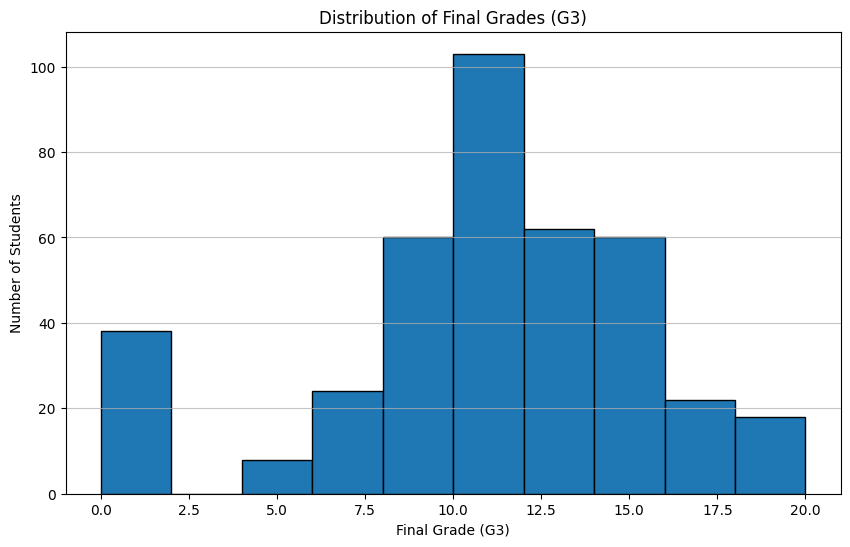

In [30]:
plt.figure(figsize=(10, 6))
plt.hist(df['G3'], bins=10, edgecolor='black')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Scatterplot of Study Time vs. Grades (G3)

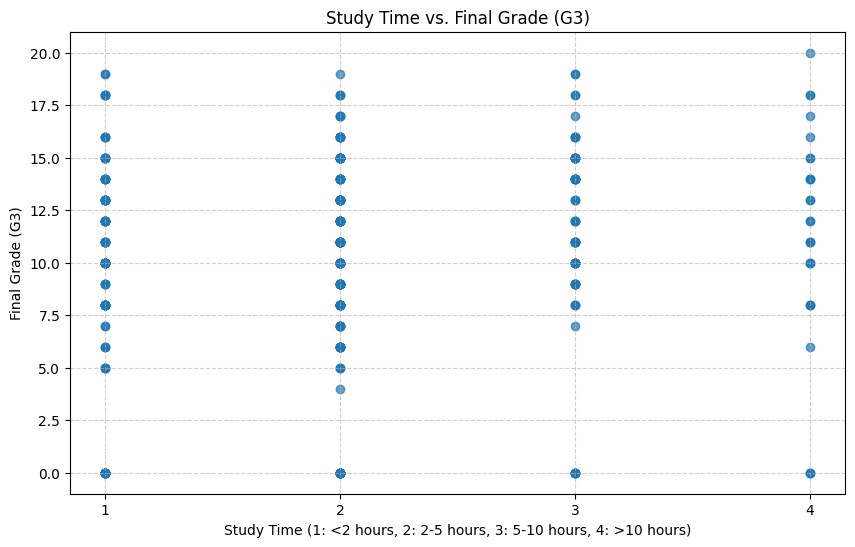

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(df['studytime'], df['G3'], alpha=0.7)
plt.title('Study Time vs. Final Grade (G3)')
plt.xlabel('Study Time (1: <2 hours, 2: 2-5 hours, 3: 5-10 hours, 4: >10 hours)')
plt.ylabel('Final Grade (G3)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks([1, 2, 3, 4])
plt.show()

### Bar Chart: Male vs. Female Average Scores (G3)

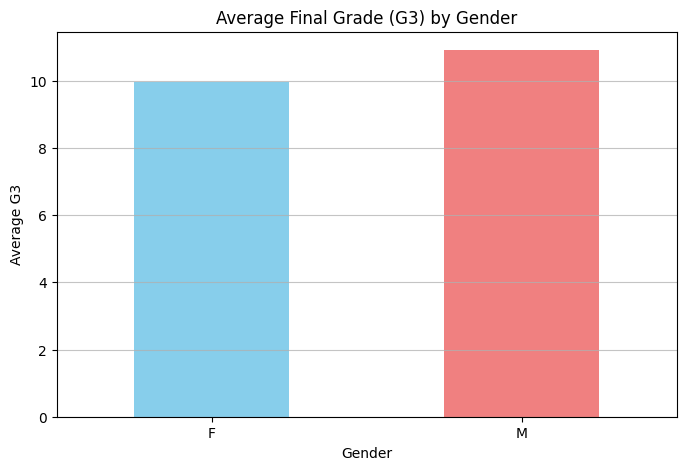

In [32]:
plt.figure(figsize=(8, 5))
gender_performance.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Average Final Grade (G3) by Gender')
plt.xlabel('Gender')
plt.ylabel('Average G3')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.75)
plt.show()

Project Summary and Output Explanation
1. Data Loading and Initial Exploration
Data Source: The dataset student-mat.csv was successfully loaded into a pandas DataFrame, df, using ; as a separator and utf-8 encoding. This resolved initial loading issues.
Initial View (df.head()): The first few rows of the DataFrame were displayed, confirming correct data parsing and showing columns such as school, sex, age, G1, G2, G3, etc.
Statistical Summary (df.describe()): A summary of numerical columns provided insights into the distribution of age, Medu, Fedu, studytime, failures, absences, and the grades G1, G2, G3. For instance, the average age is around 16.7, and the average G3 is approximately 10.42.
Missing Values (df.isnull().sum()): It was confirmed that there are no missing values across any of the columns, indicating a clean dataset in this regard.
Duplicate Values (df.duplicated().sum()): No duplicate rows were found in the dataset.
Data Shape (df.shape): The DataFrame contains 395 rows and 33 columns.
Data Types (df.dtypes): The data types of all columns were inspected, showing a mix of object (for categorical features like school, sex, address) and int64 (for numerical features like age, studytime, G3).
2. Key Analysis Questions
Average Final Grade (G3): The average final grade (G3) among all students is 10.42.
Students Scoring Above 15 (G3): There are 40 students who achieved a final grade (G3) higher than 15.
Correlation between Study Time and Performance (G3): The correlation coefficient between studytime and G3 is 0.10. This indicates a weak positive correlation, suggesting that while more study time might generally be associated with slightly higher grades, it's not a strong linear relationship.
Gender Performance Comparison (Average G3):
Average G3 for Female students (F): 9.97
Average G3 for Male students (M): 10.91
Conclusion: Male students performed better on average with a G3 of 10.91 compared to female students with a G3 of 9.97.
3. Visualizations
Histogram of Final Grades (G3): This visualization showed the distribution of G3 grades. It revealed that the grades are somewhat clustered around the mid-range (10-15), with fewer students achieving very low or very high grades. There's a notable peak around 10-12.

A visual plot of the histogram was generated.

Scatterplot of Study Time vs. Grades (G3): This scatterplot illustrated the relationship between the categorical studytime (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h) and G3. The plot visually supported the weak positive correlation, showing a general upward trend in grades with increased study time, but also a wide spread of grades within each study time category.

A visual plot of the scatterplot was generated.

Bar Chart: Male vs. Female Average Scores (G3): This bar chart clearly depicted the average G3 for male and female students. The bar for male students was visibly higher than that for female students, confirming the numerical finding that male students had a higher average final grade.

A visual plot of the bar chart was generated.

Overall Project Summary
This project involved loading and exploring a student performance dataset, followed by answering specific analytical questions and creating relevant visualizations. We successfully identified key statistics such as the average final grade, the number of high-scoring students, and a weak positive correlation between study time and grades. Furthermore, we found that male students, on average, achieved slightly higher final grades than female students. The generated visualizations provided clear graphical representations of the grade distribution, the relationship between study time and performance, and the gender-based grade differences.

This analysis lays a foundation for further investigation into factors influencing student performance, potentially leading to interventions or policy changes to support academic success.